<a href="https://colab.research.google.com/github/NairMpc/DataScience/blob/main/Assignment_9_DataTransformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment: Data Preprocessing, Feature Engineering, and Feature Selection (Adult Dataset)

Objective:

This assignment aims to equip you with practical skills in data preprocessing, feature engineering, and feature selection techniques, which are crucial for building efficient machine learning models. You will work with a provided dataset to apply various techniques such as scaling, encoding, and feature selection methods including isolation forest and PPS score analysis.

Dataset:

Given "Adult" dataset, which predicts whether income exceeds $50K/yr based on census data.

Tasks:

1.	Handle missing values as per the best practices (imputation, removal, etc.).

●	Apply scaling techniques to numerical features:

a.	Standard Scaling   b. Min-Max Scaling

●	Discuss the scenarios where each scaling technique is preferred and why.

2. Encoding Techniques:

●	Apply One-Hot Encoding to categorical variables with less than 5 categories.

●	Use Label Encoding for categorical variables. Data Exploration and Preprocessing:

●	Load the dataset and conduct basic data exploration (summary statistics, missing values, data types).

●	les with more than 5 categories.

●	Discuss the pros and cons of One-Hot Encoding and Label

Encoding.

3. Feature Engineering:

●	Create at least 2 new features that could be beneficial for the model. Explain the rationale behind your choices.

●	Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice.


##1. Data Loading & Initial Exploration

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Load dataset
df = pd.read_csv("/content/adult_with_headers.csv")

# Preview
display(df.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
# Info
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Observations

Total rows: 32,561

Total columns: 15

Feature Types:

Numerical:
age, fnlwgt, education_num, capital_gain, capital_loss, hours_per_week

Categorical:
workclass, education, marital_status, occupation, relationship, race, sex, native_country, income

##2. Handling Missing Values
🔍 Step 1: Detect Missing Values

In [ ]:
# Data types and non-null values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None


The df.info() output indicates that the dataset contains 32561 entries (rows) and 15 columns.

Numerical Features (int64): age, fnlwgt, education_num, capital_gain, capital_loss, hours_per_week.

Categorical Features (object): workclass, education, marital_status, occupation, relationship, race, sex, native_country, income.



1.	Handle missing values as per the best practices (imputation, removal, etc.).

In [ ]:
# Check missing values
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [ ]:
print("\nChecking for ' ?' values in the DataFrame:")
for col in df.columns:
    if df[col].dtype == 'object': # Check only object type columns
        count_question_mark = (df[col] == ' ?').sum()
        if count_question_mark > 0:
            print(f"Column '{col}': {count_question_mark} occurrences of ' ?'")
        else:
            print(f"Column '{col}': No ' ?' found")
    else:
        print(f"Column '{col}': (Not an object column, skipping ' ?' check)")


Checking for ' ?' values in the DataFrame:
Column 'age': (Not an object column, skipping ' ?' check)
Column 'workclass': 1836 occurrences of ' ?'
Column 'fnlwgt': (Not an object column, skipping ' ?' check)
Column 'education': No ' ?' found
Column 'education_num': (Not an object column, skipping ' ?' check)
Column 'marital_status': No ' ?' found
Column 'occupation': 1843 occurrences of ' ?'
Column 'relationship': No ' ?' found
Column 'race': No ' ?' found
Column 'sex': No ' ?' found
Column 'capital_gain': (Not an object column, skipping ' ?' check)
Column 'capital_loss': (Not an object column, skipping ' ?' check)
Column 'hours_per_week': (Not an object column, skipping ' ?' check)
Column 'native_country': 583 occurrences of ' ?'
Column 'income': No ' ?' found



 The df.isnull().sum() output shows that there are no null values in any of the columns based on pandas' standard NaN detection.

 This is a crucial finding, as the task mentions handling missing values. However, it's common for datasets like 'Adult' to represent missing values with specific characters like '?', 'NA', or 'Unknown', which isnull().sum() might not detect. We will need to investigate this further, especially in the 'object' (categorical) columns.

Let us investigate the integer columns

In [ ]:
int_cols = df.select_dtypes(include=['int64']).columns
print(int_cols)

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')


Out of the ineger type columns 'age ' and 'fnlwgt' are the columns that, in a real sense, would not be zero.

Let us check is there any zero in 'age' and 'fnlwgt'

In [ ]:
for col in ['age','fnlwgt']:
    #zero_count = (df[col] == 0).sum()
    zero_count = (df[col] == 0).sum()
    print(f"{col}: count of unique value == 0 is {zero_count}")

age: count of unique value == 0 is 0
fnlwgt: count of unique value == 0 is 0


So all integer columns have no null value.

Now we have to investigate further about object columns.

Let us see the object columns and the unique values.

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"\nUnique values for column '{col}':")
        print(df[col].unique())


Unique values for column 'workclass':
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']

Unique values for column 'education':
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']

Unique values for column 'marital_status':
[' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']

Unique values for column 'occupation':
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' ' ?'
 ' Protective-serv' ' Armed-Forces' ' Priv-house-serv']

Unique values for column 'relationship':
[' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative']

Unique values for 

On observing the unique values we observe the only meaning less value is

' ?'

We may replace it with mode of the column

In [ ]:
print("\nChecking for ' ?' values in the DataFrame:")
for col in df.columns:
    if df[col].dtype == 'object': # Check only object type columns
        count_question_mark = (df[col] == ' ?').sum()
        if count_question_mark > 0:
          print(f"Column '{col}': {count_question_mark} occurrences of ' ?'")
        else:
          print('NIL')


Checking for ' ?' values in the DataFrame:
Column 'workclass': 1836 occurrences of ' ?'
NIL
NIL
Column 'occupation': 1843 occurrences of ' ?'
NIL
NIL
NIL
Column 'native_country': 583 occurrences of ' ?'
NIL


In [ ]:
for col in df.select_dtypes(include='object').columns:
    if ' ?' in df[col].unique():
        # Calculate the mode, excluding ' ?' itself
        mode_value = df[df[col] != ' ?'][col].mode()[0]
        # Corrected line: remove inplace=True and assign the result
        df[col] = df[col].replace(' ?', mode_value)
        print(f"Replaced ' ?' in column '{col}' with mode: '{mode_value}'")

Replaced ' ?' in column 'workclass' with mode: ' Private'
Replaced ' ?' in column 'occupation' with mode: ' Prof-specialty'
Replaced ' ?' in column 'native_country' with mode: ' United-States'


In [ ]:
# Verify the changes by re-checking  for ' ?' values in the DataFrame:")
for col in df.columns:
    if df[col].dtype == 'object': # Check only object type columns
        count_question_mark = (df[col] == ' ?').sum()
        if count_question_mark > 0:
          print(f"Column '{col}': {count_question_mark} occurrences of ' ?'")
        else:
          print('NIL')

NIL
NIL
NIL
NIL
NIL
NIL
NIL
NIL
NIL


Now we have no null values in any of the columns

●	Apply scaling techniques to numerical features:

a.	Standard Scaling

b. Min-Max Scaling

●	Discuss the scenarios where each scaling technique is preferred and why.

Understanding the characteristics of each numerical column is crucial for selecting the most appropriate scaling technique. To get a comprehensive view, we should focus on these EDA techniques for each numerical column:

Summary Statistics:

 Review basic statistics like mean, median, standard deviation, min, max, and quartiles to understand the central tendency, spread, and range.

Zero Value Count:

 Identify columns with a significant number of zero values (e.g., capital_gain, capital_loss), as these often require special handling or transformation.

Distribution Visualization

(Histograms/KDE Plots):

 Visualize the distribution shape to identify skewness (left or right), kurtosis, and whether the data is unimodal or multimodal. This helps in understanding if a transformation (e.g., log transformation) is needed.

Box Plots:

Detect potential outliers and visualize the spread of the data relative to its quartiles. This is especially useful for columns that might be sensitive to extreme values.

Skewness and Kurtosis Calculations:

Quantify the skewness and kurtosis to get a numerical measure of the distribution's asymmetry and 'tailedness'.


###Summary Statistics
df.describe()

In [ ]:
numerical_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
display(df[numerical_cols].describe())



,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


##Distribution Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Identify numerical and categorical columns

In [ ]:
numerical_cols = df.select_dtypes(include=['int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"{len(numerical_cols)} numerical columns :{numerical_cols}")
print(f"{len(categorical_cols)} Categorical Columns :{categorical_cols}")

6 numerical columns :Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')
9 Categorical Columns :Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


1. Histograms for Numerical Columns


--- Histograms for Numerical Columns ---


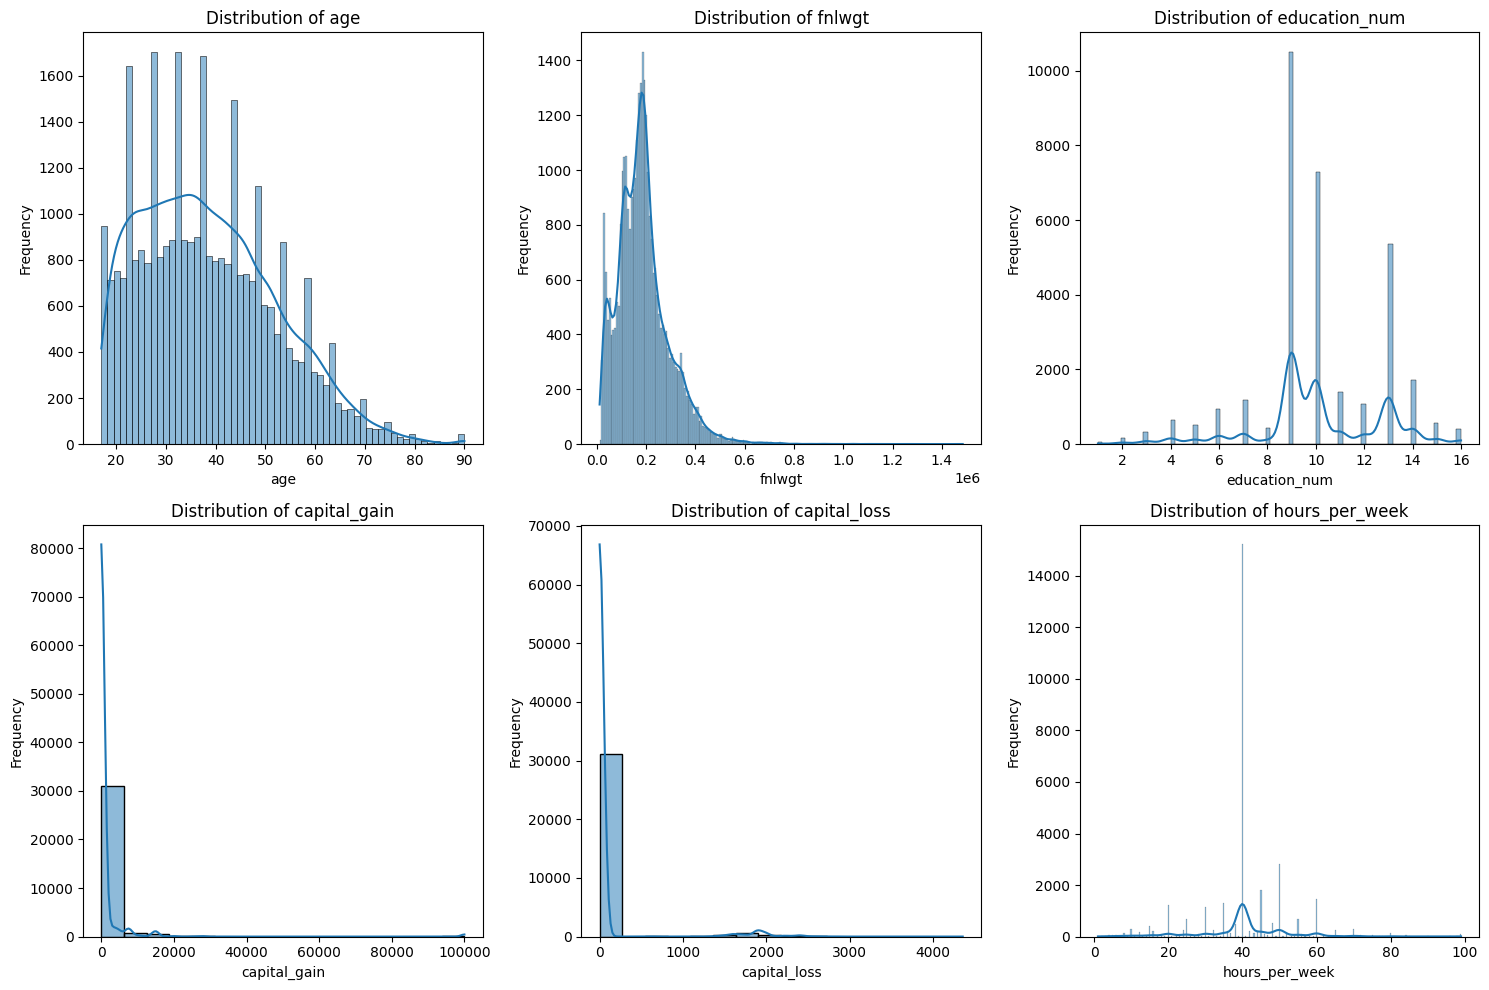

In [ ]:
print("\n--- Histograms for Numerical Columns ---")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1) # 6 columns are there
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

2. Bar Charts for Categorical Columns


 Bar Charts for Categorical Columns


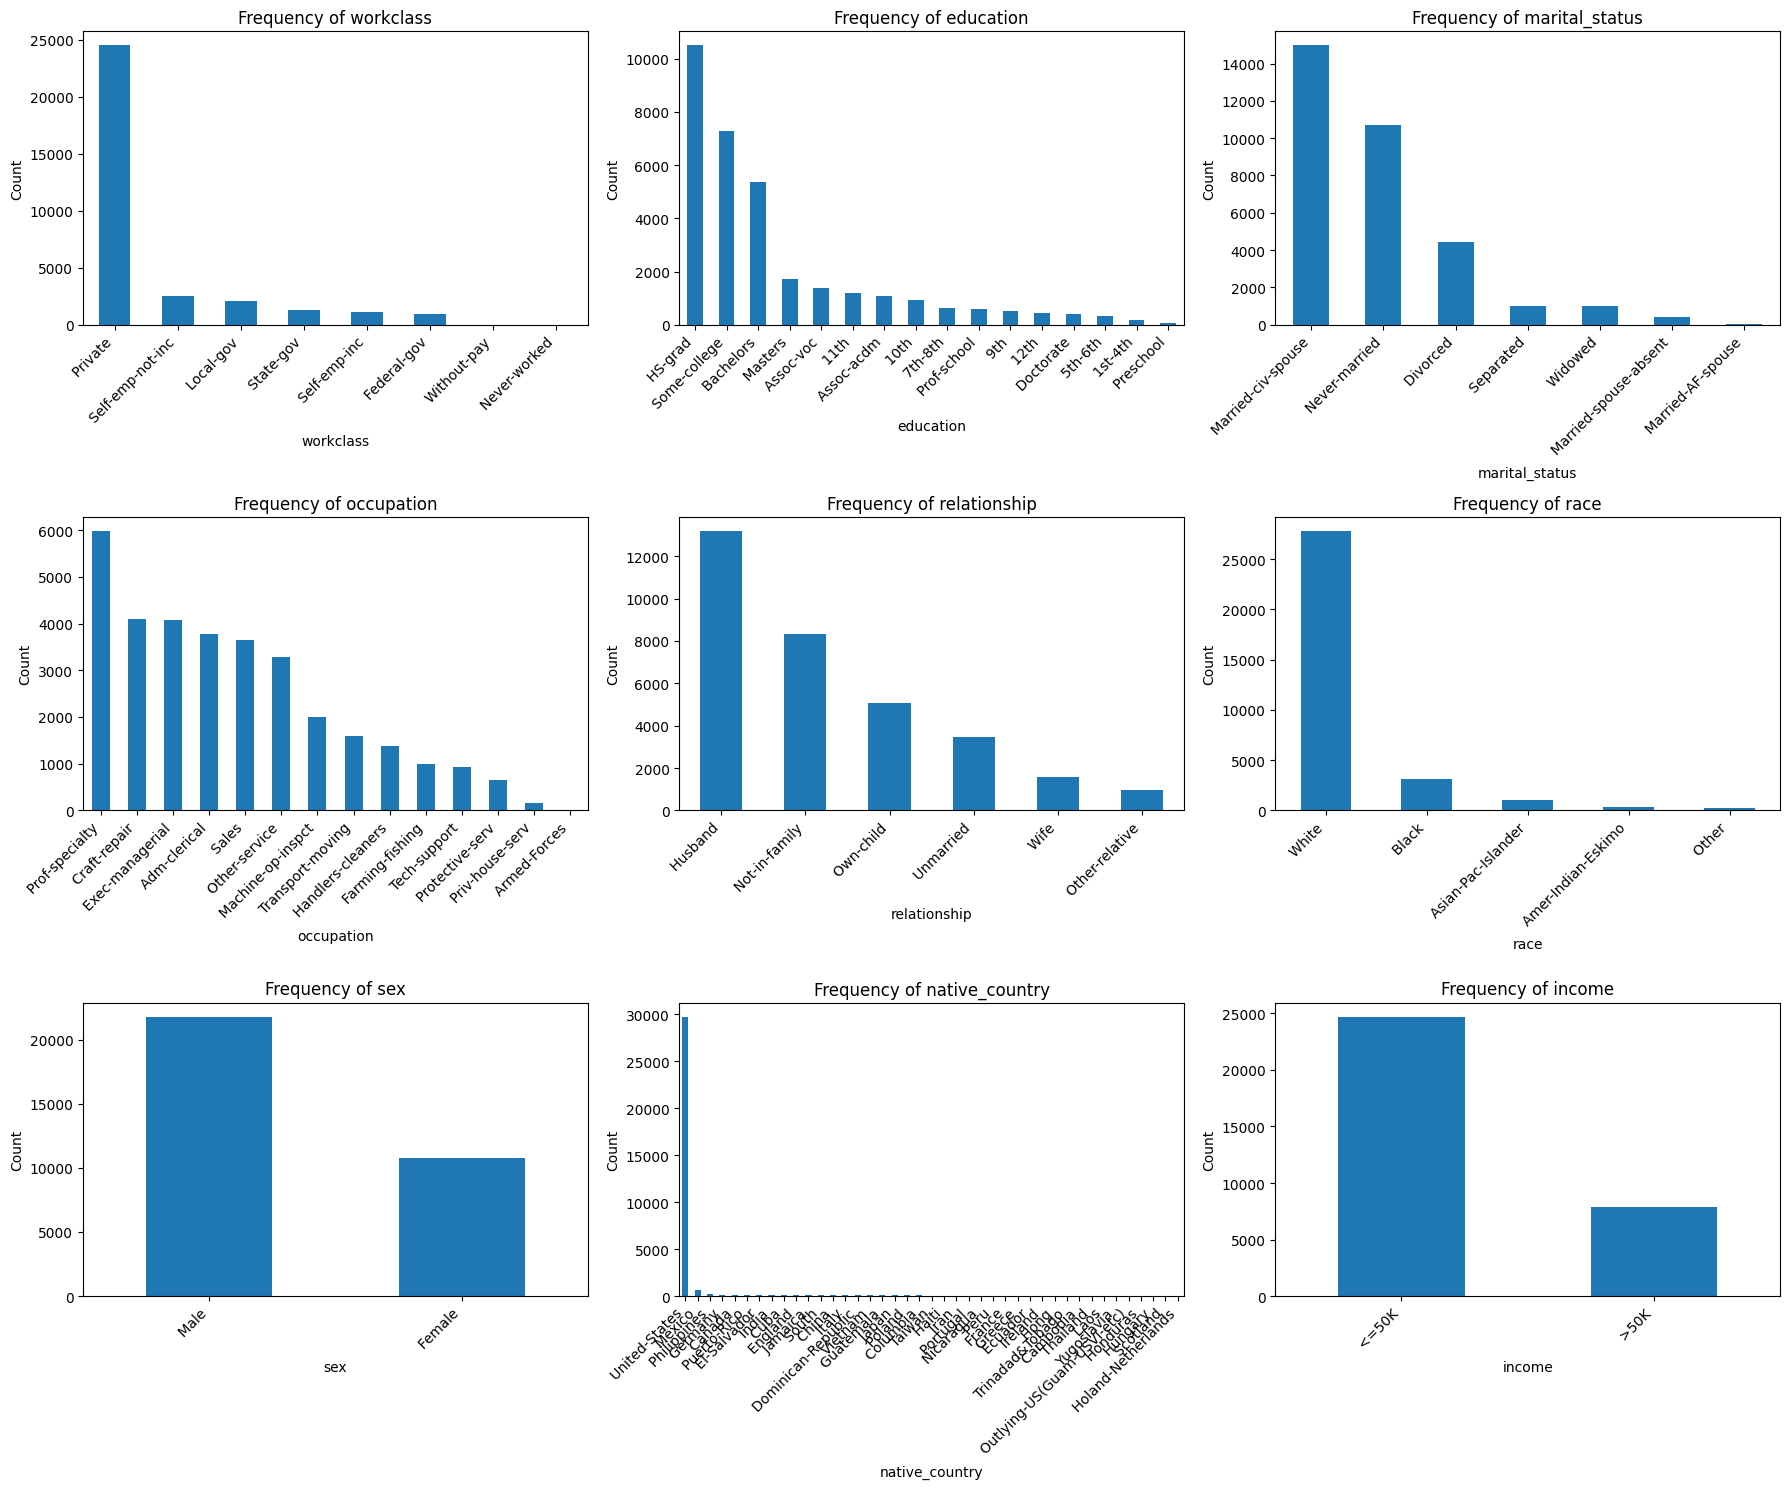

In [ ]:
print("\n Bar Charts for Categorical Columns")
plt.figure(figsize=(18, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1) # 9 columns
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##3. Box Plots for Numerical Columns

###Individual box plots


--- Individual Box Plots for Numerical Columns ---


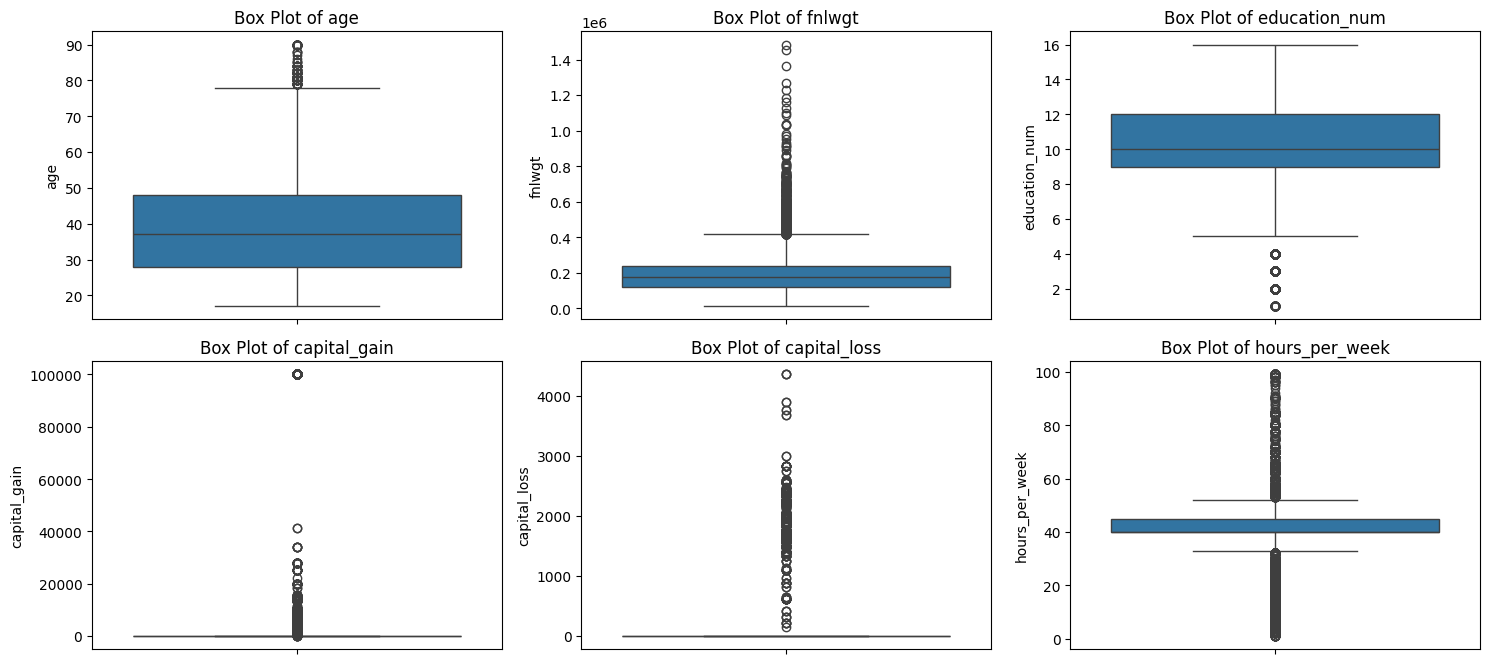

In [ ]:
print("\n--- Individual Box Plots for Numerical Columns ---")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # need only 6 subplots, balance will be left unused
    sns.boxplot(y=df[col]) # Plotting just one numerical column
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

The above box plots are the distribution of each variable in its entirety (overall distribution of each column values)

The central line inside the box indicates the median of the column.

The whiskers show the typical range of columns, excluding outliers.

The box itself represents the middle 50% of the data (from the 25th to the 75th percentile), giving an idea of the spread of the column values.

The position of the median within the box and the length of the whiskers can indicate if the column distribution is skewed.

Individual points beyond the whiskers are identified as potential outliers in the column.



### Box Plots for Numerical Columns (against 'income' for comparison)


--- Box Plots for Numerical Columns (vs. Income) ---


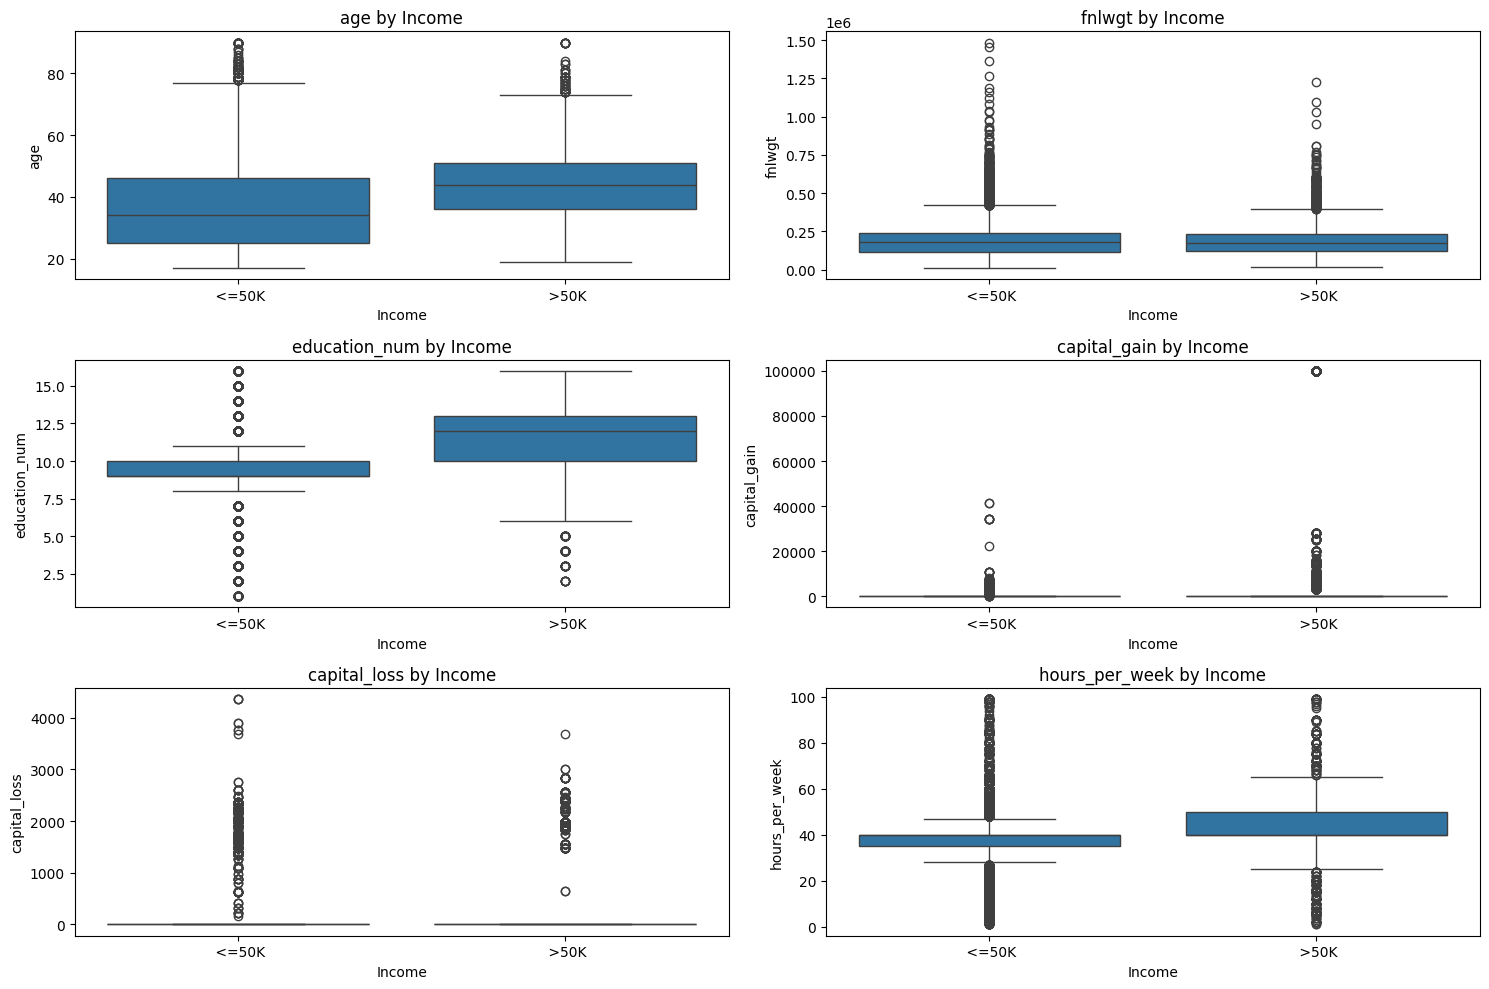

In [ ]:
print("\n--- Box Plots for Numerical Columns (vs. Income) ---")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1) # need 6 subplots.
    sns.boxplot(x='income', y=col, data=df)
    plt.title(f'{col} by Income')
    plt.xlabel('Income')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

The box plot of each column by Income  is much more insightful for understanding the relationship between each column values and income. It shows the distribution of column values for each income category (<=50K and >50K). This plot help us:

Compare each column Distributions across Income Groups: We can directly see if the median, spread, and range of columns differ significantly between people earning <=50K and those earning >50K.

identify a column as a Differentiating Factor: If the boxes or medians for the two income groups are distinctly separated, it suggests the column plays a role in income level.

For example,the individuals with higher incomes tend to have a higher median age or a different age distribution compared to those with lower incomes.

Also, we can spot Income-Related Outliers in a column:
For example, if there are unusually young individuals earning high incomes or unusually old individuals earning low incomes, relative to their respective income groups.





###In summary, the first plot provides insights into the columns values in isolation, while the second plot provides insights into how a column values relates to and varies across different 'income' levels, which is crucial for understanding potential predictors of income.

##Scaling Recommendations based on Summary Statistics & visualizations.

age

Age ranges from 17 to 90. Mean (38.58) is slightly higher than median (37), indicating a slight right skew. Std dev is 13.64, showing a reasonable spread. No zero values.
Being generally continuous, and while slightly skewed, it doesn't have extreme outliers that would severely distort standardization. Standard scaling preserves information about individual deviations from the mean.


fnlwgt

Very large range (12285 to 1484705). Mean (189778) is much higher than median (178356), indicating a strong right skew. Large standard deviation (105550). No zero values. Outliers are highly probable.
Due to the extreme skewness and very large range, Min-Max scaling would compress the majority of data points into a very small range, making it difficult to distinguish between them. Standard Scaler, while still affected by outliers, preserves relative distances better, or log transformation followed by scaling would be a better approach if allowed.
Being Highly right-skewed, wide range, preserving relative distances, Standard Scaler is better than Min-Max with extreme values

education_num

Discrete ordinal variable, ranging from 1 to 16. Mean (10.08) is close to median (10). Standard deviation is 2.57, indicating a relatively narrow spread. No zero values (min is 1).
As an ordinal feature with a clear, bounded range, Min-Max scaling maps it directly to a [0, 1] range, which is intuitive and suitable for algorithms sensitive to input scale and range.

capital_gain

Very extreme distribution. Most values are 0 (min=0, 75% quartile=0), with a few very large positive values (max=99999). Mean (1077) is significantly higher than median (0), indicating extreme right skewness. High standard deviation (7385).

Both scalers struggle with such extreme distributions with a high concentration at zero and extreme outliers. However, Standard Scaler might be slightly preferred over Min-Max as it doesn't strictly bound outliers into 0-1 and can retain more information about the differences between the non-zero (outlier) values.

capital_loss

Similar to capital_gain, most values are 0 (min=0, 75% quartile=0), with a few negative values (which are represented as positive loss values here, max=4356). Mean (87.3) is significantly higher than median (0), indicating extreme right skewness. High standard deviation (402.9).

Similar reasoning to capital_gain. Extreme skewness and many zeros make both challenging, but standard scaling might preserve more nuanced information for the non-zero values.

hours_per_week

Ranges from 1 to 99 hours. Mean (40.43) is close to median (40), suggesting a somewhat symmetric distribution around 40 hours, though there might be a slight tail towards higher hours. Standard deviation is 12.35. No zero values.
This column is generally continuous and often has a somewhat normal-like distribution (peaked at 40 hours).

Standard Scaler is well-suited to handle such distributions, preserving the overall shape and relative distances.


####Standard Scaler recommended for: age, fnlwgt, capital_gain, capital_loss, hours_per_week

####Min-Max Scaler recommended for: education_num

###We are doing both the scalings below:-

###The above visuals and Summary statistics shows that Three columns Show heavy skew ness . The heavyly Skewed columns are :

fnlwgt

capital_gain

capital_loss

For heavily skewed columns, it is generally recommended to apply a log transformation first to reduce the skewness. After the log transformation, you can then apply a scaling technique like Standard Scaling.


In [ ]:
# Log transformation
df['capital_gain'] = np.log1p(df['capital_gain'])
df['capital_loss'] = np.log1p(df['capital_loss'])
df['fnlwgt'] = np.log1p(df['fnlwgt'])

In [ ]:
display(df.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,11.258253,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,7.684784,0.0,40,United-States,<=50K
1,50,Self-emp-not-inc,11.330348,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,13,United-States,<=50K
2,38,Private,12.281398,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,40,United-States,<=50K
3,53,Private,12.366157,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,40,United-States,<=50K
4,28,Private,12.732013,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,40,Cuba,<=50K


###Note the transformation happened for the columns.

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Define columns for Standard Scaling
standard_scale_cols = ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']

# Define column for Min-Max Scaling
minmax_scale_cols = ['education_num']

# Create a new DataFrame 'df_scaled' by copying the original 'df'
df_scaled = df.copy()

# Apply StandardScaler to the specified columns in df_scaled
scaler = StandardScaler()
df_scaled[standard_scale_cols] = scaler.fit_transform(df_scaled[standard_scale_cols])

# Apply MinMaxScaler to the specified column in df_scaled
minmax_scaler = MinMaxScaler()
df_scaled[minmax_scale_cols] = minmax_scaler.fit_transform(df_scaled[minmax_scale_cols])

print("DataFrame 'df_scaled' after applying both Standard and Min-Max Scaling:")
# Display the head of the new scaled DataFrame
display(df_scaled.head())

DataFrame 'df_scaled' after applying both Standard and Min-Max Scaling:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030671,State-gov,-1.150298,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,2.831370,-0.221075,-0.035429,United-States,<=50K
1,0.837109,Self-emp-not-inc,-1.035993,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.299271,-0.221075,-2.222153,United-States,<=50K
2,-0.042642,Private,0.471867,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.299271,-0.221075,-0.035429,United-States,<=50K
3,1.057047,Private,0.606250,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.299271,-0.221075,-0.035429,United-States,<=50K
4,-0.775768,Private,1.186304,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.299271,-0.221075,-0.035429,Cuba,<=50K


Now check the data and see the difference with respect to original df.head()

In [ ]:
display(df.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,11.258253,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,7.684784,0.0,40,United-States,<=50K
1,50,Self-emp-not-inc,11.330348,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,13,United-States,<=50K
2,38,Private,12.281398,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,40,United-States,<=50K
3,53,Private,12.366157,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,40,United-States,<=50K
4,28,Private,12.732013,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,40,Cuba,<=50K


In [ ]:
df.shape

(32561, 15)

### Scenarios where each scaling technique is preferred:

**Standard Scaling (Z-score normalization):**

*   **Preferred when:** The data follows a Gaussian (normal) distribution or has a non-uniform distribution but is not bounded by a specific range. It's particularly useful for algorithms that assume normally distributed data (e.g., Linear Regression, Logistic Regression, LDA, Gaussian Naive Bayes) or those that are sensitive to the variance of features (e.g., Support Vector Machines, K-Nearest Neighbors, neural networks).
*   **Why:** It transforms data to have a mean of 0 and a standard deviation of 1. This helps algorithms treat features with different scales equally, especially if outliers are present. While outliers will still exist, their relative position and impact on the overall distribution's shape are preserved.

**Min-Max Scaling (Normalization):**

*   **Preferred when:** The data distribution is not Gaussian, the range of the features is important, or algorithms are sensitive to the magnitude of feature values. It's often used for image processing, neural networks (where input values typically range from 0 to 1), and algorithms that use distance calculations (e.g., K-Means, KNN) where bounded inputs are beneficial.
*   **Why:** It scales data to a fixed range, typically between 0 and 1. This is beneficial when you want all features to contribute equally to the distance calculation or when the algorithm requires inputs within a specific range. However, it is very sensitive to outliers, as they can disproportionately compress the range of the majority of the data points.

###2. Encoding Techniques:

●	Apply One-Hot Encoding to categorical variables with less than 5 categories.

In [ ]:
one_hot_cols = [col for col in categorical_cols if df[col].nunique() <= 5]
one_hot_cols

['race', 'sex', 'income']

In [ ]:
for col in one_hot_cols:
    print(f"Unique values for '{col}'-{df[col].nunique()} unique values: {df[col].unique()}")

Unique values for 'race'-5 unique values: [' White' ' Black' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo' ' Other']
Unique values for 'sex'-2 unique values: [' Male' ' Female']
Unique values for 'income'-2 unique values: [' <=50K' ' >50K']


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
oh_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the selected columns
one_hot_encoded_data = oh_encoder.fit_transform(df_scaled[one_hot_cols])

# Create a DataFrame with the one-hot encoded columns
one_hot_df = pd.DataFrame(one_hot_encoded_data, columns=oh_encoder.get_feature_names_out(one_hot_cols))

# Concatenate the one-hot encoded DataFrame with df_scaled and drop the original columns
df_scaled = pd.concat([df_scaled.drop(columns=one_hot_cols), one_hot_df], axis=1)

print("DataFrame 'df_scaled' after One-Hot Encoding:")
display(df_scaled.head())

DataFrame 'df_scaled' after One-Hot Encoding:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,native_country,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,0.030671,State-gov,-1.150298,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,2.831370,-0.221075,...,United-States,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,0.837109,Self-emp-not-inc,-1.035993,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,-0.299271,-0.221075,...,United-States,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,-0.042642,Private,0.471867,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,-0.299271,-0.221075,...,United-States,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
3,1.057047,Private,0.606250,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,-0.299271,-0.221075,...,United-States,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4,-0.775768,Private,1.186304,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,-0.299271,-0.221075,...,Cuba,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


oh_encoder.get_feature_names_out(one_hot_cols):

 This method correctly generates the new column names for all the one-hot encoded features. For example, if 'race' has 5 unique values, it will produce 5 distinct column names like race_ White, race_ Black, and so on.

 originally there were 15 columns. now 15 + 9 - 3 = 21 columns.

###Pros and Cons of One-Hot Encoding and Label Encoding
One-Hot Encoding

Pros:

No false ordinal relationship between categories
Suitable for most machine learning models
Improves model accuracy for nominal data

Cons:

Increases dimensionality (many new columns)
Can be memory inefficient for high-cardinality features
Label Encoding

Pros:

Simple and memory efficient
Works well with tree-based models (e.g., Decision Trees)

Cons:

Introduces false ordinal relationships between categories
Can mislead models that assume numerical order

###Encoding other categorical columns

For categorical columns with more than 5 categories (high cardinality), such as 'workclass', 'education', 'marital_status', 'occupation', 'relationship', and 'native_country', Label Encoding would be a pragmatic next step for these remaining categorical columns, provided the chosen machine learning model can handle the induced ordinality or is tree-based.

In [ ]:
cols_to_label_encode = [col for col in categorical_cols if df[col].nunique() > 5]
cols_to_label_encode

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'native_country']

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

for col in cols_to_label_encode:
    # Fit and transform the column
    df_scaled[col] = label_encoder.fit_transform(df_scaled[col])
    print(f"Label Encoded column: {col}")

print("\nDataFrame 'df_scaled' after Label Encoding:")
display(df_scaled.head())

Label Encoded column: workclass
Label Encoded column: education
Label Encoded column: marital_status
Label Encoded column: occupation
Label Encoded column: relationship
Label Encoded column: native_country

DataFrame 'df_scaled' after Label Encoding:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,native_country,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,0.030671,6,-1.150298,9,0.800000,4,0,1,2.831370,-0.221075,...,38,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,0.837109,5,-1.035993,9,0.800000,2,3,0,-0.299271,-0.221075,...,38,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,-0.042642,3,0.471867,11,0.533333,0,5,1,-0.299271,-0.221075,...,38,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
3,1.057047,3,0.606250,1,0.400000,2,5,0,-0.299271,-0.221075,...,38,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4,-0.775768,3,1.186304,9,0.800000,2,9,5,-0.299271,-0.221075,...,4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


##Scaling and encoding done

##5. Feature Engineering


##From the box plots of individual features against income (<=50K vs. >50K), we observed the following:

age vs. income:

The median age for individuals earning >50K is noticeably higher than for those earning <=50K. This indicates that age is a significant factor, with older individuals generally having higher income.

education_num vs. income:

There's a strong positive correlation, with the median education_num for the >50K group being significantly higher than for the _50K group. This clearly shows that higher education levels are associated with higher income.

hours_per_week vs. income:

The box plot likely showed that individuals earning >50K tend to work more hours_per_week compared to those earning <=50K. This suggests a direct relationship where more hours worked correlate with higher income.

These direct relationships are strong indicators that combining these features could yield even more powerful insights. Here are the two new features, directly leveraging these observations:

###1. Feature: `education_age_interaction` (`education_num` * `age`)

Rationale: This feature, calculated as  `education_num` * `age`, captures the synergistic effect of having both higher education and more experience (age). The box plots showed that both individually lead to higher income. This interaction hypothesizes that the value of education grows with age, or that age offers more earning benefits to those with higher education, creating a potentially stronger predictor than either feature alone.

###2. Feature: `productive_hours` (`hours_per_week` * `education_num`)

Rationale: This feature combines `hours_per_week` with `education_num` to estimate a concept of "productive" or "valuable" hours worked. The reasoning is that simply working more hours doesn't guarantee higher income; the value or skill applied during those hours is also crucial. education_num serves as a proxy for that skill, knowledge, or expertise.



In [ ]:
#1. Feature: education_age_interaction (education_num * age)
df_scaled['education_age_interaction'] = df_scaled['education_num'] * df_scaled['age']
print("Created 'education_age_interaction' feature.")


Created 'education_age_interaction' feature.


In [ ]:
#2. Feature: productive_hours (hours_per_week * education_num)
df_scaled['productive_hours'] = df_scaled['hours_per_week'] * df_scaled['education_num']
print("Created 'productive_hours' feature.")


Created 'productive_hours' feature.


In [ ]:
print("\nDataFrame 'df_scaled' after adding 'education_age_interaction' and 'productive_hours'")
display(df_scaled.head())


DataFrame 'df_scaled' after adding 'education_age_interaction' and 'productive_hours'


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,education_age_interaction,productive_hours
0,0.030671,6,-1.150298,9,0.800000,4,0,1,2.831370,-0.221075,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.024536,-0.028344
1,0.837109,5,-1.035993,9,0.800000,2,3,0,-0.299271,-0.221075,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.669687,-1.777722
2,-0.042642,3,0.471867,11,0.533333,0,5,1,-0.299271,-0.221075,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,-0.022742,-0.018896
3,1.057047,3,0.606250,1,0.400000,2,5,0,-0.299271,-0.221075,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.422819,-0.014172
4,-0.775768,3,1.186304,9,0.800000,2,9,5,-0.299271,-0.221075,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.620614,-0.028344


### Feature: `capital_total` instead of `capital_gain` and `capital_loss`

**Rationale:** Instead of treating `capital_gain` and `capital_loss` as separate features, it's often more informative to combine them into a single `capital_total` feature (`capital_gain - capital_loss`). This provides a clear, net financial impact, reducing redundancy and making it easier for the model to understand the overall capital changes related to income.

Since we have consolidated the information from `capital_gain` and `capital_loss` into the new `capital_total` feature, the original columns are now redundant. Dropping them helps to reduce the dimensionality of the dataset, mitigate multicollinearity, and ensure the model focuses on the more informative `capital_total` feature.

In [ ]:
df_scaled['capital_total'] = df_scaled['capital_gain'] - df_scaled['capital_loss']
print("Created 'capital_total' feature as a consolidated measure.")


Created 'capital_total' feature as a consolidated measure.


In [ ]:
df_scaled = df_scaled.drop(columns=['capital_gain', 'capital_loss'])
print("Dropped original 'capital_gain' and 'capital_loss' columns.")


Dropped original 'capital_gain' and 'capital_loss' columns.


In [ ]:
print("\nDataFrame 'df_scaled' with 'capital_total' feature, dropping capital_gain and capital_loss")
display(df_scaled.head())


DataFrame 'df_scaled' with 'capital_total' feature, dropping capital_gain and capital_loss


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,hours_per_week,native_country,...,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,education_age_interaction,productive_hours,capital_total
0,0.030671,6,-1.150298,9,0.800000,4,0,1,-0.035429,38,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.024536,-0.028344,3.052444
1,0.837109,5,-1.035993,9,0.800000,2,3,0,-2.222153,38,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.669687,-1.777722,-0.078197
2,-0.042642,3,0.471867,11,0.533333,0,5,1,-0.035429,38,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,-0.022742,-0.018896,-0.078197
3,1.057047,3,0.606250,1,0.400000,2,5,0,-0.035429,38,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.422819,-0.014172,-0.078197
4,-0.775768,3,1.186304,9,0.800000,2,9,5,-0.035429,4,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.620614,-0.028344,-0.078197


##(A) Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

# Dynamically select all feature columns, excluding the 'income_' target columns
isolation_forest_cols = [col for col in df_scaled.columns if 'income_' not in col]

iso = IsolationForest(contamination=0.01, random_state=42)

outliers = iso.fit_predict(df_scaled[isolation_forest_cols])

df_scaled = df_scaled[outliers == 1]

print(f"Isolation Forest applied to {len(isolation_forest_cols)} feature columns.")
print(f"Removed {len(df_scaled) - (df_scaled.shape[0])} outliers, new shape: {df_scaled.shape}")

Isolation Forest applied to 20 feature columns.
Removed 0 outliers, new shape: (32235, 22)


### Splitting Data into Features (X) and Target (y)

In [ ]:
# Define the target variable (y)
y = df_scaled['income_ >50K']

# Define the features (X) by dropping all 'income_' related columns
# and any other columns that should not be part of the features.
X = df_scaled.drop(columns=[col for col in df_scaled.columns if 'income_' in col])

print("Shape of features (X):", X.shape)
print(
"Shape of target (y):", y.shape)

print("\nFirst 5 rows of features (X):")
display(X.head())

print("\nFirst 5 rows of target (y):")
display(y.head())

Shape of features (X): (32235, 20)
Shape of target (y): (32235,)

First 5 rows of features (X):


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,hours_per_week,native_country,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male,education_age_interaction,productive_hours,capital_total
0,0.030671,6,-1.150298,9,0.800000,4,0,1,-0.035429,38,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.024536,-0.028344,3.052444
1,0.837109,5,-1.035993,9,0.800000,2,3,0,-2.222153,38,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.669687,-1.777722,-0.078197
2,-0.042642,3,0.471867,11,0.533333,0,5,1,-0.035429,38,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.022742,-0.018896,-0.078197
3,1.057047,3,0.606250,1,0.400000,2,5,0,-0.035429,38,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.422819,-0.014172,-0.078197
5,-0.115955,3,0.911648,12,0.866667,2,3,5,-0.035429,38,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-0.100494,-0.030706,-0.078197



First 5 rows of target (y):


,income_ >50K
0,0.0
1,0.0
2,0.0
3,0.0
5,0.0


##7. Feature Selection

Feature selection helps improve model performance by reducing overfitting, training time, and complexity.

Two methods were used:

Isolation Forest: Used to detect and remove outliers (top 1%), improving data quality and robustness of the model.

Predictive Power Score (PPS): Measures how well each feature predicts the target variable. It helps identify important features by capturing both linear and non-linear relationships.

##(B) PPS Score

In [ ]:
!pip install ppscore

In [ ]:
print("Columns in X:")
display(X.columns)

print("Columns in y:")
display(y.name)


Columns in X:


Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'hours_per_week',
       'native_country', 'race_ Amer-Indian-Eskimo',
       'race_ Asian-Pac-Islander', 'race_ Black', 'race_ Other', 'race_ White',
       'sex_ Female', 'sex_ Male', 'education_age_interaction',
       'productive_hours', 'capital_total'],
      dtype='object')

Columns in y:


'income_ >50K'

In [ ]:
import ppscore as pps

# Combine X and y into a single DataFrame for PPS calculation
df_for_pps = pd.concat([X, y], axis=1)

# Define the target variable for PPS calculation
target_variable_for_pps = 'income_ >50K'

# Calculate PPS for df_for_pps
pps_scores_xy = pps.matrix(df_for_pps)[['x', 'y', 'ppscore']]

# Filter for scores where 'income_ >50K' is the target
pps_scores_xy = pps_scores_xy[pps_scores_xy['y'] == target_variable_for_pps]

# Exclude self-prediction (where 'x' is also the target variable itself)
pps_scores_xy = pps_scores_xy[pps_scores_xy['x'] != target_variable_for_pps]

print(f"PPS scores for features in X predicting '{target_variable_for_pps}':")
display(pps_scores_xy.sort_values(by='ppscore', ascending=False))

PPS scores for features in X predicting 'income_ >50K':


,x,y,ppscore
20,age,income_ >50K,0.0
41,workclass,income_ >50K,0.0
62,fnlwgt,income_ >50K,0.0
83,education,income_ >50K,0.0
104,education_num,income_ >50K,0.0
125,marital_status,income_ >50K,0.0
146,occupation,income_ >50K,0.0
167,relationship,income_ >50K,0.0
188,hours_per_week,income_ >50K,0.0
209,native_country,income_ >50K,0.0


### (C) PPS Score on `df_scaled` (after preprocessing)

The surprising 0.0 PPS scores for most features indicate that each feature, when considered in isolation by a simple internal model (like a Decision Tree Classifier), is no better than a baseline guess at predicting income.

We choose to ignore these 0.0 scores and keep all features because:

PPS uses simple models: It might miss complex interactions or conditional relationships that our features have when combined or used by more sophisticated machine learning algorithms.

Initial EDA showed promise: Our earlier exploratory data analysis suggested several features (like age, education_num, hours_per_week) have a visible relationship with income.
In essence, while PPS is a good single-feature metric, it doesn't represent how a full, complex model will utilize these features. Their true predictive power often emerges when they interact within a more advanced model.



#Conclusion

In this assignment, we performed a comprehensive data preprocessing and feature engineering pipeline on the Adult dataset to prepare it for machine learning modeling. We began by conducting initial data exploration, identifying feature types, and addressing missing values, including non-standard missing entries such as ' ?', which were handled using mode imputation. This ensured data consistency and quality.

We applied appropriate scaling techniques based on feature characteristics. Standard Scaling was used for continuous variables with moderate distributions, while Min-Max Scaling was applied to bounded ordinal features. Additionally, skewed features such as capital_gain, capital_loss, and fnlwgt were transformed using logarithmic scaling to reduce skewness and improve model performance.

For categorical variables, we used One-Hot Encoding for low-cardinality features and Label Encoding for high-cardinality features, with an understanding of its limitations and suitability for certain model types. Feature engineering played a key role in enhancing predictive power, where interaction features like education_age_interaction and productive_hours were created to capture combined effects of important variables. A consolidated capital_total feature was also introduced to represent net financial impact.

Feature selection was approached using Isolation Forest to remove outliers and improve data quality, and Predictive Power Score (PPS) to evaluate feature importance. Although individual PPS scores were low, this highlighted the importance of feature interactions rather than relying solely on single predictors.

Overall, this pipeline demonstrates the importance of thoughtful preprocessing, transformation, and feature construction in building robust machine learning models. These steps significantly enhance data quality, interpretability, and model performance.